In [43]:
import os
import torch
from torch.utils.data import random_split, DataLoader, Dataset
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim


import torchvision
from torchvision import transforms
from PIL import Image

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

import os
import kagglehub

In [44]:
class AstroUniversalDataset(Dataset):
    def __init__(self, csv_path, galaxy_zoo_img_dir, planet_dir, other_dirs, transform=None, sample_limit=150):
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        self.class_to_idx = {
            "Spiral": 0, "Elliptical": 1, "Nebula": 2, "Planetary": 3, "Star Cluster": 4
        }
        
        print("Indexing Galaxy Zoo...")
        df = pd.read_csv(csv_path)
        
        elliptical_df = df[(df['Class1.1'] >= 0.80) & ((df['Class7.1'] + df['Class7.2']) >= 0.70)]
        elliptical_ids = elliptical_df['GalaxyID'].tolist()
        
        spiral_df = df[(df['Class1.2'] >= 0.80) & (df['Class4.1'] >= 0.75)]
        spiral_ids = spiral_df['GalaxyID'].tolist()
        
        self._extract_galaxy_zoo(spiral_ids, galaxy_zoo_img_dir, self.class_to_idx["Spiral"], sample_limit)
        self._extract_galaxy_zoo(elliptical_ids, galaxy_zoo_img_dir, self.class_to_idx["Elliptical"], sample_limit)

        print("Indexing Planetary subfolders...")
        planet_label = self.class_to_idx["Planetary"]

        total_planet_count = 0  
        
        for folder_name in sorted(os.listdir(planet_dir)):
            folder_path = os.path.join(planet_dir, folder_name)
            if os.path.isdir(folder_path):
                
                current_planet_count = 0 
                for filename in os.listdir(folder_path):
                    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.image_paths.append(os.path.join(folder_path, filename))
                        self.labels.append(planet_label)
                        
                        current_planet_count += 1
                        total_planet_count += 1
                        
                        if current_planet_count >= 18:    
                            break
                            
        print(f"Added {total_planet_count} total planet images (18 per subfolder).")

        print("Indexing static image directories...")
        for class_name, folder_path in other_dirs.items():
            if class_name not in self.class_to_idx:
                continue
            
            idx = self.class_to_idx[class_name]
            count = 0
            for filename in os.listdir(folder_path):
                if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.image_paths.append(os.path.join(folder_path, filename))
                    self.labels.append(idx)
                    count += 1
                    if count >= sample_limit:
                        break
                        
        print(f"Dataset initialization complete. Total samples: {len(self.image_paths)}")

    
    def _extract_galaxy_zoo(self, galaxy_ids, img_dir, label_idx, sample_limit):
        count = 0
        for g_id in galaxy_ids:
            img_path = os.path.join(img_dir, f"{g_id}.jpg")
            if os.path.exists(img_path):
                self.image_paths.append(img_path)
                self.labels.append(label_idx)
                count += 1
                if count >= sample_limit:
                    break

    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.long)

In [1]:
import zipfile
import os

os.makedirs("/kaggle/working/galaxy_zoo/images", exist_ok=True)

with zipfile.ZipFile("/kaggle/input/competitions/galaxy-zoo-the-galaxy-challenge/training_solutions_rev1.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/galaxy_zoo/")

with zipfile.ZipFile("/kaggle/input/competitions/galaxy-zoo-the-galaxy-challenge/images_training_rev1.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/galaxy_zoo/images")

In [46]:
CSV_PATH = "/kaggle/working/galaxy_zoo/training_solutions_rev1.csv"
GALAXY_ZOO_DIR = "/kaggle/working/galaxy_zoo/images/images_training_rev1"
PLANETS = "/kaggle/input/private-dataset/Planets_Moons_Data/Planets and Moons"

OTHER_DIRECTORIES = {
    "Nebula": "/kaggle/input/datasets/arpitmahajan09/nebulae-dataset",
    "Star Cluster": "/kaggle/input/datasets/arpitmahajan09/star-clusters-dataset/star_clusters_dataset"
}

from torchvision import transforms
astroTransfrom = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = AstroUniversalDataset(
    csv_path=CSV_PATH,
    galaxy_zoo_img_dir=GALAXY_ZOO_DIR,
    planet_dir = PLANETS, 
    other_dirs=OTHER_DIRECTORIES,
    transform=astroTransfrom,
    sample_limit=150 
)

Indexing Galaxy Zoo...
Indexing Planetary subfolders...
Added 198 total planet images (18 per subfolder).
Indexing static image directories...
Dataset initialization complete. Total samples: 782


In [47]:
totalSize = len(dataset)
trainSize = int(len(dataset)*0.8)
testSize = totalSize-trainSize

generator = torch.Generator().manual_seed(42)
trainDataset, testDataset = random_split(dataset, [trainSize, testSize], generator=generator)

trainTransform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

testTransform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

import copy
testDataset.dataset = copy.copy(dataset)

trainDataset.dataset.transform = trainTransform
testDataset.dataset.transform = testTransform


print(f"Train Size ={trainSize}, Test Size = {testSize}")

Train Size =625, Test Size = 157


In [48]:
BATCH_SIZE = 32
trainLoader = DataLoader(trainDataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
testLoader = DataLoader(testDataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# Using resnet18 pretrained model here

for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_ftrs, 5)
)

In [49]:
model.load_state_dict(torch.load('/kaggle/working/astro_resnet18_best.pth'))
model.eval() 
print("Pre-trained model loaded")
# Works only after a kaggle model is trained in the current session 

Pre-trained model loaded and ready for inference!


In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"model loaded and moved to: {device}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001,weight_decay=1e-4)

model loaded and moved to: cpu


## Testing 

Visualizing a random batch from the training set:


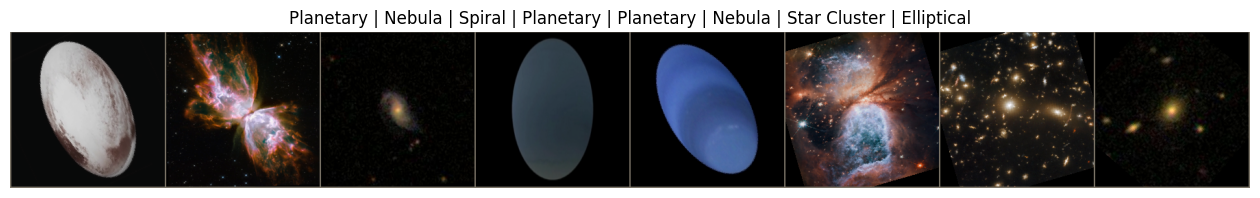

In [51]:
test_loader = DataLoader(trainDataset, batch_size=8, shuffle=True)


images, labels = next(iter(test_loader))
idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}

def imshow(inp, title=None):
    """Function to un-normalize and display a PyTorch tensor as an image."""
    inp = inp.numpy().transpose((1, 2, 0))
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1) 
    
    plt.figure(figsize=(16, 4))
    plt.imshow(inp)
    if title is not None:
        plt.title(title, fontsize=12)
    plt.axis('off')
    plt.show()


out = torchvision.utils.make_grid(images, nrow=8)
class_names = [idx_to_class[label.item()] for label in labels]

print("Visualizing a random batch from the training set:")
imshow(out, title=" | ".join(class_names))

### Continued Code

In [52]:
EPOCHS = 12
print(f"Starting training on device: {device}...")


train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for images, labels in trainLoader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()      
        outputs = model(images)
        loss = criterion(outputs, labels) 
        loss.backward()    
        optimizer.step()      
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    
    model.eval()
    test_loss, correct_test, total_test = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in testLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            test_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
            
    epoch_test_loss = test_loss / total_test
    epoch_test_acc = correct_test / total_test
    test_losses.append(epoch_test_loss)
    test_accuracies.append(epoch_test_acc)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] -> "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc*100:.2f}% | "
          f"Test Loss: {epoch_test_loss:.4f}, Test Acc: {epoch_test_acc*100:.2f}%")

print("\nTraining Complete!")

Starting training on device: cpu...
Epoch [1/12] -> Train Loss: 1.5050, Train Acc: 32.00% | Test Loss: 1.5055, Test Acc: 28.66%
Epoch [2/12] -> Train Loss: 1.3661, Train Acc: 36.96% | Test Loss: 1.2482, Test Acc: 43.31%
Epoch [3/12] -> Train Loss: 1.2992, Train Acc: 36.64% | Test Loss: 1.1171, Test Acc: 43.95%
Epoch [4/12] -> Train Loss: 1.2598, Train Acc: 42.72% | Test Loss: 1.0275, Test Acc: 51.59%
Epoch [5/12] -> Train Loss: 1.2421, Train Acc: 38.40% | Test Loss: 1.0106, Test Acc: 50.32%
Epoch [6/12] -> Train Loss: 1.1700, Train Acc: 43.36% | Test Loss: 0.9720, Test Acc: 55.41%
Epoch [7/12] -> Train Loss: 1.1943, Train Acc: 44.80% | Test Loss: 0.9361, Test Acc: 57.96%
Epoch [8/12] -> Train Loss: 1.0784, Train Acc: 50.72% | Test Loss: 0.9609, Test Acc: 52.87%
Epoch [9/12] -> Train Loss: 1.1382, Train Acc: 46.72% | Test Loss: 0.9087, Test Acc: 52.87%
Epoch [10/12] -> Train Loss: 1.0980, Train Acc: 47.68% | Test Loss: 0.9273, Test Acc: 60.51%
Epoch [11/12] -> Train Loss: 1.1637, Train 

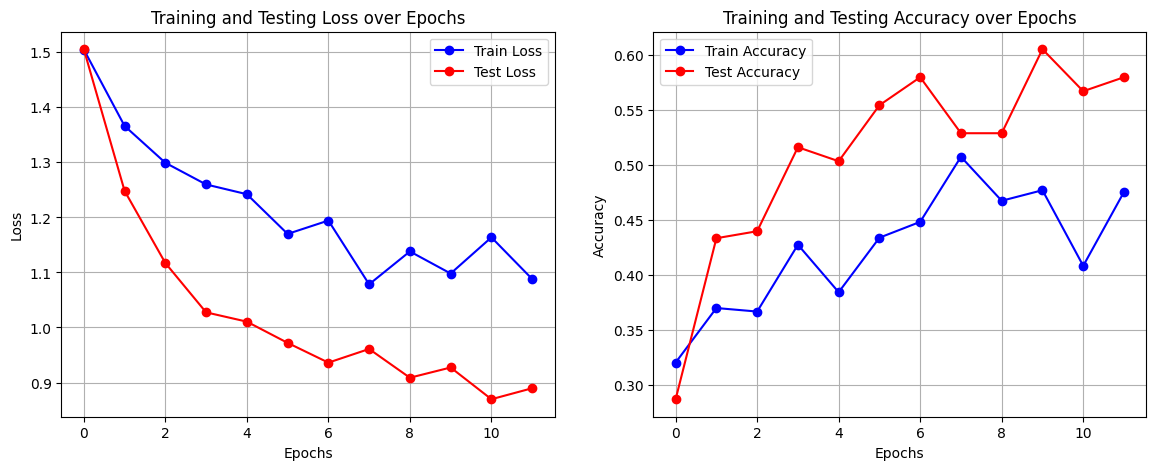

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue', marker='o')
plt.plot(test_losses, label='Test Loss', color='red', marker='o')
plt.title('Training and Testing Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', color='blue', marker='o')
plt.plot(test_accuracies, label='Test Accuracy', color='red', marker='o')
plt.title('Training and Testing Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

In [63]:
MODEL_PATH = '/kaggle/working/astro_resnet18_best.pth'
torch.save(model.state_dict(), MODEL_PATH)
print(f"Model successfully saved to {MODEL_PATH}")

Model successfully saved to /kaggle/working/astro_resnet18_best.pth


## Grad-CAM

In [55]:
!pip install grad-cam

In [56]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

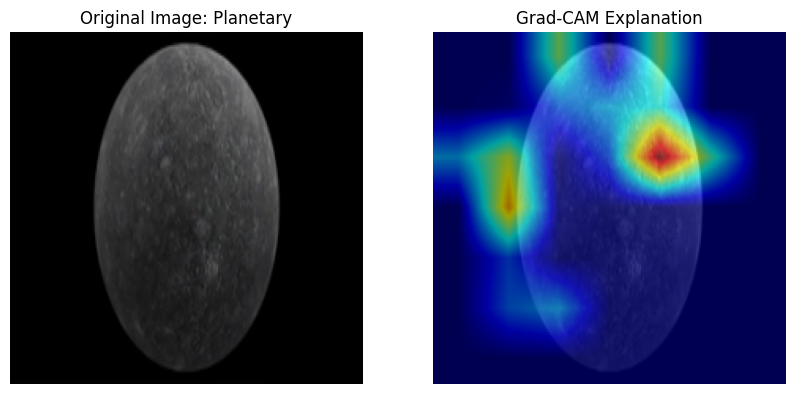

In [64]:
model.eval()
target_layers = [model.layer4[-1]]


cam = GradCAM(model=model, target_layers=target_layers)

images, labels = next(iter(testLoader))
input_tensor = images[0].unsqueeze(0).to(device) # Add batch dimension
input_tensor.requires_grad = True
true_label = labels[0].item()
targets = [ClassifierOutputTarget(true_label)]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]


mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img = images[0].numpy().transpose((1, 2, 0))
img = std * img + mean
img = np.clip(img, 0, 1)


visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)


idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
class_name = idx_to_class[true_label]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img)
axs[0].set_title(f"Original Image: {class_name}")
axs[0].axis('off')

axs[1].imshow(visualization)
axs[1].set_title("Grad-CAM Explanation")
axs[1].axis('off')

plt.show()

## Gradio

In [65]:
import gradio as gr
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [66]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights=None) 


num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.5), 
    nn.Linear(num_ftrs, 5)
)
model.load_state_dict(torch.load('/kaggle/working/astro_resnet18_best.pth', map_location=device))
model = model.to(device)
model.eval()


val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)


class_names = ["Spiral Galaxy", "Elliptical Galaxy", "Nebula", "Planetary Object", "Star Cluster"]

In [67]:
def predict_and_explain(input_image):
    if input_image is None:
        return None, None

    
    input_tensor = val_transforms(input_image).unsqueeze(0).to(device)
    
    input_tensor.requires_grad = True
    outputs = model(input_tensor)
    probabilities = torch.nn.functional.softmax(outputs[0], dim=0).detach().cpu().numpy()
    
    confidences = {class_names[i]: float(probabilities[i]) for i in range(5)}
    predicted_class_idx = np.argmax(probabilities)
    
    targets = [ClassifierOutputTarget(predicted_class_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

    img_resized = input_image.resize((224, 224))
    img_array = np.array(img_resized) / 255.0
    visualization = show_cam_on_image(img_array, grayscale_cam, use_rgb=True)
    
    return confidences, visualization

In [ ]:
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# Astronomy Image Classifier")
    gr.Markdown("Upload an astronomical image. The model will classify it and generate an Attention Map to explain its decision.")
    
    with gr.Row():
        with gr.Column():
            image_input = gr.Image(type="pil", label="Upload Astronomical Image")
            submit_btn = gr.Button("Analyze Image", variant="primary")
            
        with gr.Column():
            label_output = gr.Label(num_top_classes=5, label="Model Predictions")
            cam_output = gr.Image(label="Grad-CAM Attention Map")
            
    submit_btn.click(fn=predict_and_explain, inputs=image_input, outputs=[label_output, cam_output])

demo.launch(share=True)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import time
import seaborn as sns

model.eval()
pred = []
labels = []

#Inference Time
start_time = time.time()

with torch.no_grad():
    for images, labels in testLoader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        pred.extend(preds.cpu().numpy())
        labels.extend(labels.cpu().numpy())

end_time = time.time()
total_time = end_time - start_time

num_images = len(testDataset)
inference_time_per_image = (total_time / num_images) * 1000 

print(f"Total Test Set Evaluation Time: {total_time:.2f} seconds")
print(f"Average Inference Time per Image: {inference_time_per_image:.2f} ms")

# Final Matries 
accuracy = accuracy_score(labels, pred)
print(f"\nFinal Test Accuracy: {accuracy * 100:.2f}%")
class_names = ["Spiral", "Elliptical", "Nebula", "Planetary", "Star Cluster"]
report = classification_report(labels, pred, target_names=class_names)
print(report)

# Confusion Matrix
cm = confusion_matrix(labels, pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=12)
plt.show()

/tmp/ipykernel_76/203719033.py:1: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


* Running on local URL:  http://127.0.0.1:7863
* Running on public URL: https://b9bf293652193a7de4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
